# Tech Challenge — Fase 3: Previsão de Atrasos de Voos nos EUA
## Machine Learning Engineering — Pós Tech FIAP
### Maria Thereza Moss

**Objetivo:** Vou usar um dataset com ~5.8 milhões de registros da aviação nos Estados Unidos para analisar e prever se um voo vai atrasar ou não. Vou usar técnicas de ML supervisionado e não supervisionado.

**Abordagem:**
- **EDA**: exploração dos dados com estatísticas descritivas e visualizações
- **Classificação supervisionada**: prever se um voo vai atrasar (>15 min) ou não
- **Clusterização não supervisionada**: agrupar aeroportos por perfil de atraso, com K-Means

---

In [1]:
# Imports gerais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imports de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Configurações visuais
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Mostrar todas as colunas no pandas
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados

O dataset é composto por 3 arquivos CSV:
- `flights.csv` (565 MB) — tabela principal com dados de ~5.8 milhões de voos de 2015
- `airports.csv` (23 KB) — informações dos 322 aeroportos (código IATA, cidade, estado, coordenadas)
- `airlines.csv` (359 B) — nomes das 14 companhias aéreas

In [2]:
# Carregar os 3 arquivos
flights = pd.read_csv('flights.csv')
airports = pd.read_csv('airports.csv')
airlines = pd.read_csv('airlines.csv')

# O dataframe principal é o flights
df = flights.copy()

print(f"Voos: {flights.shape}")
print(f"Aeroportos: {airports.shape}")
print(f"Companhias: {airlines.shape}")

Voos: (5819079, 31)
Aeroportos: (322, 7)
Companhias: (14, 2)


### 1.1 Estrutura do Dataset

In [3]:
# Ver o formato do dataset
print(f"O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas")

# Ver todas as colunas e seus tipos
print("\nTipos de dados por coluna:")
print(df.dtypes)
print('\n')

# Ver as primeiras 5 linhas
print("Ver as primeiras 5 linhas do dataset:")
df.head()

O dataset tem 5819079 linhas e 31 colunas

Tipos de dados por coluna:
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON        str
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2. Exploração dos Dados (EDA)

### 2.1 Estatísticas Descritivas

In [4]:
# Estatísticas das colunas numéricas
df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,5.819073e+06,5.714008e+06,5.714008e+06,5.819079e+06,5.726566e+06,5.726566e+06,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,1.416859e+02,1.370062e+02,1.135116e+02,8.223565e+02,1.471469e+03,7.434971e+00,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,7.521058e+01,7.421107e+01,7.223082e+01,6.077843e+02,5.221879e+02,5.638548e+00,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,1.800000e+01,1.400000e+01,7.000000e+00,2.100000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,8.500000e+01,8.200000e+01,6.000000e+01,3.730000e+02,1.054000e+03,4.000000e+00,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,1.230000e+02,1.180000e+02,9.400000e+01,6.470000e+02,1.509000e+03,6.000000e+00,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,1.730000e+02,1.680000e+02,1.440000e+02,1.062000e+03,1.911000e+03,9.000000e+00,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,7.180000e+02,7.660000e+02,6.900000e+02,4.983000e+03,2.400000e+03,2.480000e+02,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [5]:
# Estatísticas das colunas categóricas
df.describe(include='object')

,AIRLINE,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,CANCELLATION_REASON
count,5819079,5804358,5819079,5819079,89884
unique,14,4897,930,930,4
top,WN,N480HA,ATL,ATL,B
freq,1261855,3768,346836,346904,48851


### 2.2 Análise de Valores Ausentes

In [6]:
# Contar valores nulos por coluna
nulos = df.isnull().sum()
nulos_percentual = (df.isnull().sum() / len(df)) * 100

# Mostrar só as colunas que têm nulos
tabela_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Percentual (%)': nulos_percentual.round(2)
})
tabela_nulos = tabela_nulos[tabela_nulos['Nulos'] > 0].sort_values('Percentual (%)', ascending=False)
print(tabela_nulos)

                       Nulos  Percentual (%)
CANCELLATION_REASON  5729195           98.46
WEATHER_DELAY        4755640           81.72
LATE_AIRCRAFT_DELAY  4755640           81.72
AIRLINE_DELAY        4755640           81.72
SECURITY_DELAY       4755640           81.72
AIR_SYSTEM_DELAY     4755640           81.72
ELAPSED_TIME          105071            1.81
AIR_TIME              105071            1.81
ARRIVAL_DELAY         105071            1.81
ARRIVAL_TIME           92513            1.59
TAXI_IN                92513            1.59
WHEELS_ON              92513            1.59
WHEELS_OFF             89047            1.53
TAXI_OUT               89047            1.53
DEPARTURE_TIME         86153            1.48
DEPARTURE_DELAY        86153            1.48
TAIL_NUMBER            14721            0.25
SCHEDULED_TIME             6            0.00


### 2.3 Proporção de Voos Cancelados

Antes de tratar os nulos, visualizamos a proporção de voos cancelados. Como esses voos nunca saíram, não faz sentido contabilizar os atrasos dos mesmos, visto que a variável DEPARTURE_DELAY é nula. Por isso pretendo remover esses registros na próxima etapa.

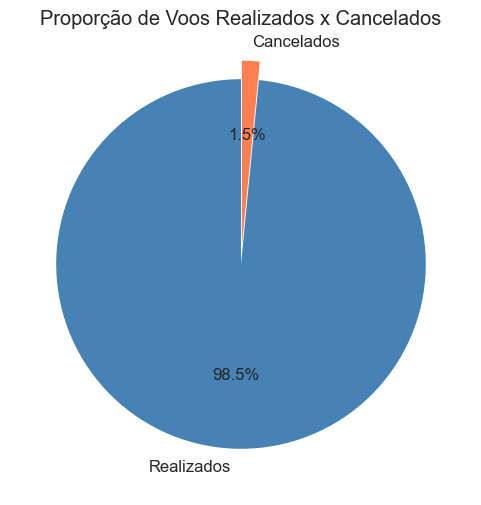

Voos realizados: 5,729,195
Voos cancelados: 89,884
Taxa de cancelamento: 1.5%


In [7]:
# Gráfico Voos cancelados vs realizados
cancelados = (df['CANCELLED'] == 1).sum() if 'CANCELLED' in df.columns else 0
realizados = (df['CANCELLED'] == 0).sum() if 'CANCELLED' in df.columns else len(df)

plt.figure(figsize=(6, 6))
plt.pie(
    [realizados, cancelados],
    labels=['Realizados', 'Cancelados'],
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90,
    explode=(0, 0.1)
)
plt.title('Proporção de Voos Realizados x Cancelados')
plt.show()

print(f'Voos realizados: {realizados:,}')
print(f'Voos cancelados: {cancelados:,}')
print(f'Taxa de cancelamento: {cancelados / (realizados + cancelados) * 100:.1f}%')


### 2.4 Tratamento de Valores Ausentes

Estratégia adotada:
- **Colunas com >80% de nulos**: 
    - Removi as colunas que apresentaram mais de 80% de dados nulos no passo 2.2
    - Pesquisando sobre o dataset, vi que elas só são preenchidas pelo sistema quando o atraso já ocorreu, para descrever a causa
    - Irrelevantes para a previsão de se o voo vai atrasar ou não no meu modelo simples
- **DEPARTURE_DELAY nulo**: linhas removidas (voos cancelados — sem dado de atraso)
- **Demais colunas numéricas**: preenchidas com a mediana
- **TAIL_NUMBER**:
    - 0,25% de nulos
    - Preenchido com 'UNKNOWN' por ser um identificador único das aeronaves

In [8]:
# Colunas com 80%+ de nulos
colunas_remover = [
    'CANCELLATION_REASON',
    'WEATHER_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'AIRLINE_DELAY',
    'SECURITY_DELAY',
    'AIR_SYSTEM_DELAY',
]
df.drop(columns=colunas_remover, inplace=True)
print(f"Removidas {len(colunas_remover)} colunas com 80%+ de nulos")

# DEPARTURE_DELAY nulo
linhas_antes = len(df)
df.dropna(subset=['DEPARTURE_DELAY'], inplace=True)
print(f"Removidas {linhas_antes - len(df)} linhas sem DEPARTURE_DELAY (voos cancelados)")

# Demais colunas númericas com poucos nulos: preencher com mediana
for col in ['ELAPSED_TIME', 'AIR_TIME', 'ARRIVAL_DELAY', 'ARRIVAL_TIME',
            'TAXI_IN', 'WHEELS_ON', 'WHEELS_OFF', 'TAXI_OUT', 'DEPARTURE_TIME']:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# TAIL_NUMBER: preencher com 'UNKNOWN'
if 'TAIL_NUMBER' in df.columns:
    df['TAIL_NUMBER'].fillna('UNKNOWN', inplace=True)

# SCHEDULED_TIME: preencher com mediana
if 'SCHEDULED_TIME' in df.columns:
    df['SCHEDULED_TIME'].fillna(df['SCHEDULED_TIME'].median(), inplace=True)

# Confirmar
print(f"\nTotal de nulos restantes: {df.isnull().sum().sum()}")
print(f"Dataset final: {df.shape[0]} linhas, {df.shape[1]} colunas")

Removidas 6 colunas com 80%+ de nulos
Removidas 86153 linhas sem DEPARTURE_DELAY (voos cancelados)

Total de nulos restantes: 81628
Dataset final: 5732926 linhas, 25 colunas


### 2.5 Visualizações

Para as visualizações, pensei em perguntas que ajudem a definir as decisões da etapa de modelagem. 

#### Gráfico 1 — Distribuição dos Atrasos de Partida

Como os atrasos são distribuídos? Existem casos extremos que possam enviesar a análise?

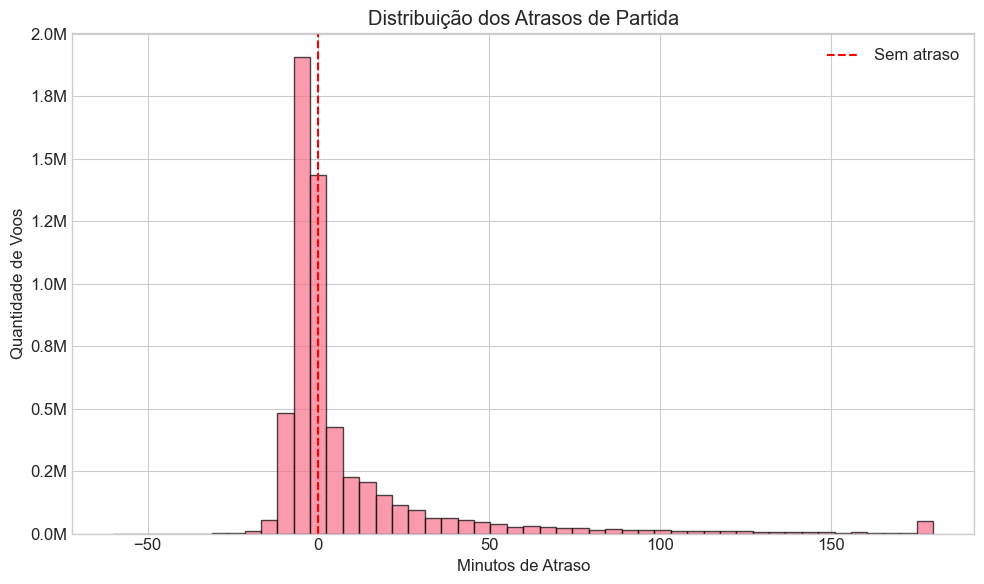

Atraso médio: 9.4 minutos
Atraso mediano: -2.0 minutos
Voos com atraso > 15 min: 1018558 (17.8%)


In [9]:
coluna_atraso = 'DEPARTURE_DELAY'

plt.figure(figsize=(10, 6))
plt.hist(df[coluna_atraso].clip(-60, 180), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Minutos de Atraso')
plt.ylabel('Quantidade de Voos')
plt.title('Distribuição dos Atrasos de Partida')
plt.axvline(x=0, color='red', linestyle='--', label='Sem atraso')
# Formatar eixo Y para mostrar valores em milhões de forma legível
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Atraso médio: {df[coluna_atraso].mean():.1f} minutos")
print(f"Atraso mediano: {df[coluna_atraso].median():.1f} minutos")
print(f"Voos com atraso > 15 min: {(df[coluna_atraso] > 15).sum()} ({(df[coluna_atraso] > 15).mean()*100:.1f}%)")

#### Gráfico 2 — Top 10 Aeroportos com Maior Atraso (versão inicial)

Responde uma das perguntas sugeridas no enunciado da Tech Challenge. O atraso é uniforme entre todos os aeroportos ou concentrado em alguns poucos? Considerei apenas aeroportos com mais de 1000 voos para evitar enviesar com aeroportos muito pequenos.

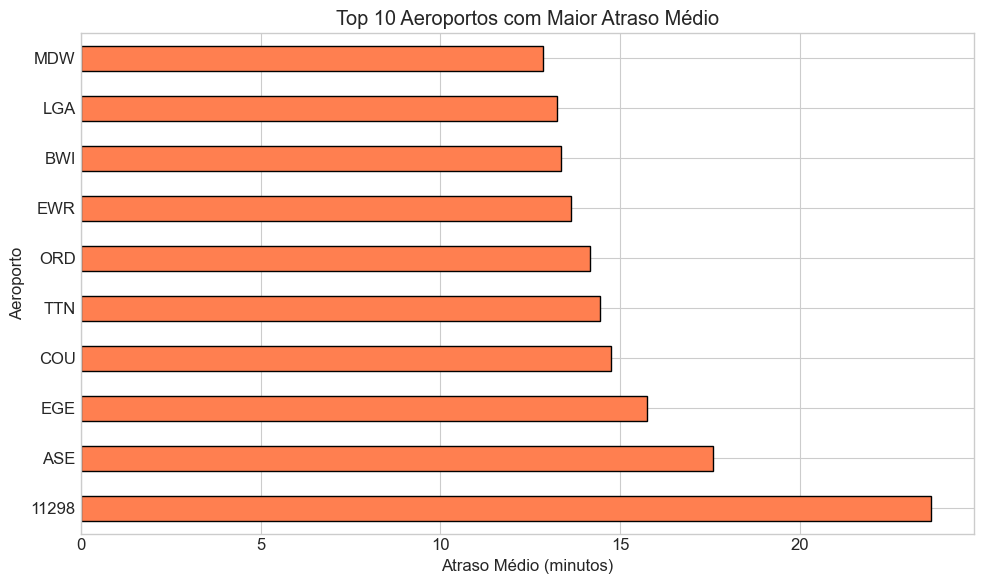

In [10]:
coluna_aeroporto = 'ORIGIN_AIRPORT'

# Calcular atraso médio por aeroporto (só os com muitos voos)
voos_por_aeroporto = df.groupby(coluna_aeroporto).size()
aeroportos_frequentes = voos_por_aeroporto[voos_por_aeroporto > 1000].index

atraso_por_aeroporto = (
    df[df[coluna_aeroporto].isin(aeroportos_frequentes)]
    .groupby(coluna_aeroporto)[coluna_atraso]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
atraso_por_aeroporto.plot(kind='barh', color='coral', edgecolor='black')
plt.xlabel('Atraso Médio (minutos)')
plt.ylabel('Aeroporto')
plt.title('Top 10 Aeroportos com Maior Atraso Médio')
plt.tight_layout()
plt.show()


#### Investigação do aeroporto 11298

Percebi um aeroporto com código numérico (ex: "11298") em vez  do padrão IATA de 3 letras e achei suspeito.

In [16]:
# Converter para texto antes de verificar
df['ORIGIN_AIRPORT'] = df['ORIGIN_AIRPORT'].astype(str)
df['DESTINATION_AIRPORT'] = df['DESTINATION_AIRPORT'].astype(str)

# Investigar
numericos = df['ORIGIN_AIRPORT'].str.isnumeric()
print(f"Aeroportos com código numérico: {numericos.sum()} voos")
print(f"Aeroportos com código letras:   {(~numericos).sum()} voos")

print("\nCódigos numéricos encontrados:")
print(df[numericos]['ORIGIN_AIRPORT'].value_counts())

Aeroportos com código numérico: 483826 voos
Aeroportos com código letras:   5249100 voos

Códigos numéricos encontrados:
ORIGIN_AIRPORT
10397    32561
13930    27609
11298    20647
11292    18106
12892    17656
         ...  
13541       11
10165        9
14222        9
13502        6
11503        4
Name: count, Length: 306, dtype: int64


Procurei na tabela `airports.csv` para entender se  esses códigos podiam ser convertidos em IATA, mas ela não traz esses números.

In [17]:
# Procurar correlação na tabela airports
print(airports.columns.tolist())
airports.head()

['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


Como representam uma quantidade mínima de voos,  optei por removê-los para manter a consistência dos dados.

In [42]:
# Remover voos com código numérico em ORIGIN_AIRPORT ou DESTINATION_AIRPORT
mascara_numerico = (
    df['ORIGIN_AIRPORT'].str.isnumeric().fillna(False) |
    df['DESTINATION_AIRPORT'].str.isnumeric().fillna(False)
)
print(f"Removendo {mascara_numerico.sum()} voos com código numérico de aeroporto")
df = df[~mascara_numerico].reset_index(drop=True)

Removendo 0 voos com código numérico de aeroporto


Também achei estranho que num gráfico com os 10 aeroportos com mais atraso, a ordem estivesse descendente. Organizei isso também na versão do gráfico corrigido.

#### Gráfico 2.1 — Top 10 Aeroportos com Maior Atraso (corrigido)

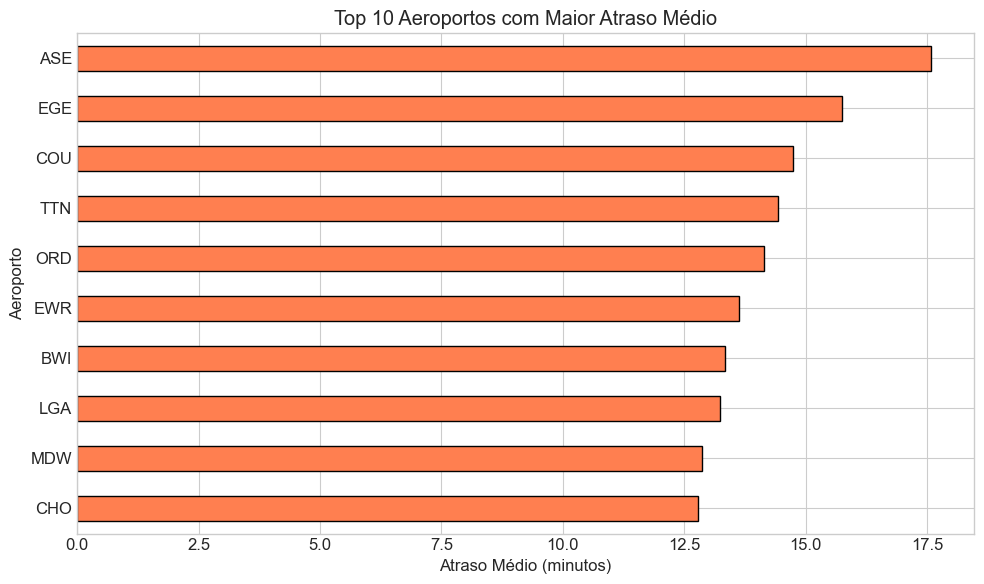

In [22]:
coluna_aeroporto = 'ORIGIN_AIRPORT'

# Calcular atraso médio por aeroporto (só os com muitos voos)
voos_por_aeroporto = df.groupby(coluna_aeroporto).size()
aeroportos_frequentes = voos_por_aeroporto[voos_por_aeroporto > 1000].index

atraso_por_aeroporto = (
    df[df[coluna_aeroporto].isin(aeroportos_frequentes)]
    .groupby(coluna_aeroporto)[coluna_atraso]
    .mean()
    .sort_values(ascending=False)
    .head(10)                        # pega os 10 maiores
    .sort_values(ascending=True)     # reordena para o gráfico
)

plt.figure(figsize=(10, 6))
atraso_por_aeroporto.plot(kind='barh', color='coral', edgecolor='black')
plt.xlabel('Atraso Médio (minutos)')
plt.ylabel('Aeroporto')
plt.title('Top 10 Aeroportos com Maior Atraso Médio')
plt.tight_layout()
plt.show()


#### Gráfico 3 — Atraso Médio por Dia da Semana

Atrasa mais nos finais de semana? Ou é o contrário?

Como no dataset original, a coluna DAY_OF_WEEK tem formato numérico (de 1 a 7), precisei antes entender qual valor corresponde a qual dia da semana, para facilitar a visualização.

Verifiquei qual número corresponde a qual dia da semana usando uma data conhecida dentro da amostra (1 de janeiro de 2015 foi quinta-feira):

In [11]:
amostra = df[(df['MONTH'] == 1) & (df['DAY'] == 1)]
print(f"1 de janeiro de 2015: DAY_OF_WEEK = {amostra['DAY_OF_WEEK'].iloc[0]}")

1 de janeiro de 2015: DAY_OF_WEEK = 4


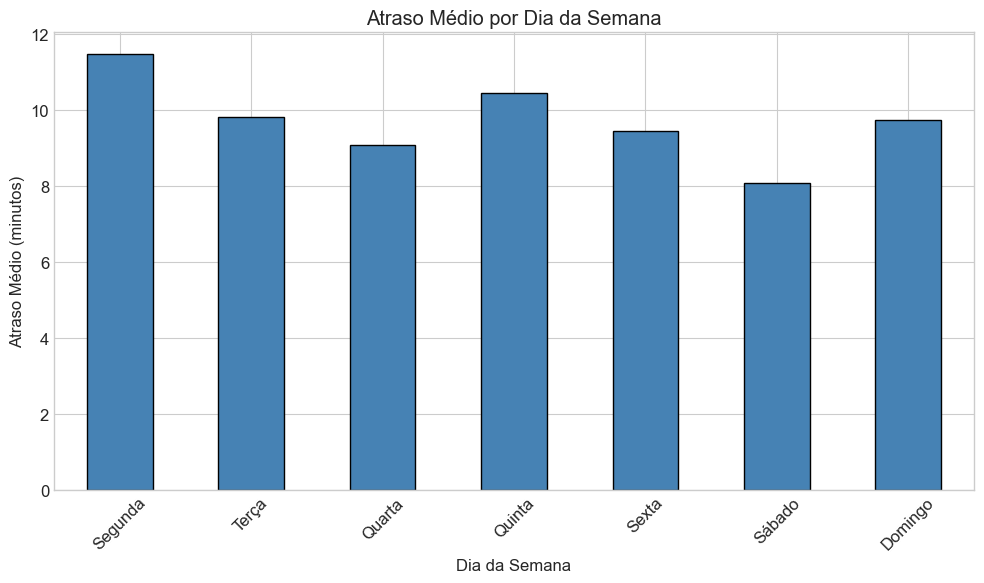

In [23]:
coluna_dia = 'DAY_OF_WEEK'

dias_nome = {1: 'Segunda', 2: 'Terça', 3: 'Quarta', 4: 'Quinta',
             5: 'Sexta', 6: 'Sábado', 7: 'Domingo'}

atraso_por_dia = df.groupby(coluna_dia)[coluna_atraso].mean()
atraso_por_dia.index = atraso_por_dia.index.map(dias_nome)

plt.figure(figsize=(10, 6))
atraso_por_dia.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Dia da Semana')
plt.ylabel('Atraso Médio (minutos)')
plt.title('Atraso Médio por Dia da Semana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Gráfico 4 — Atraso Médio por Companhia Aérea

Algumas companhias atrasam mais do que outras? Para um passageiro, faria sentido escolher uma determinada cia. aérea para tentar garantir que o voo não atrase?

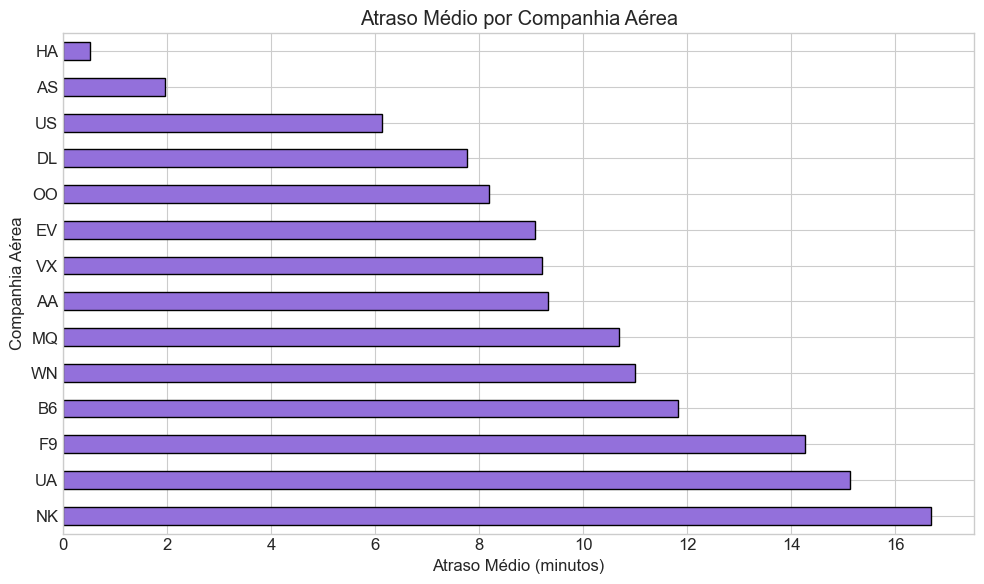

In [ ]:
coluna_companhia = 'AIRLINE'

atraso_por_companhia = (
    df.groupby(coluna_companhia)[coluna_atraso]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
atraso_por_companhia.plot(kind='barh', color='mediumpurple', edgecolor='black')
plt.xlabel('Atraso Médio (minutos)')
plt.ylabel('Companhia Aérea')
plt.title('Atraso Médio por Companhia Aérea')
plt.tight_layout()
plt.show()


#### Gráfico 5 — Matriz de Correlação

Para identificar redundância entre as variáveis numéricas e remover as excedentes.

Para não poluir muito a visualização, precisei reduzir o número de colunas exibidas. Dentre as colunas que sobraram após a remoção de colunas com dados ausentes (seção 2.4), a seleção de `colunas_relevantes` foi baseada em:
1. Apenas variáveis numéricas (categóricas não entram em matriz de correlação)
2. Excluídas colunas de informações pós-voo óbvias (pois não ajudam a prever atraso futuro)

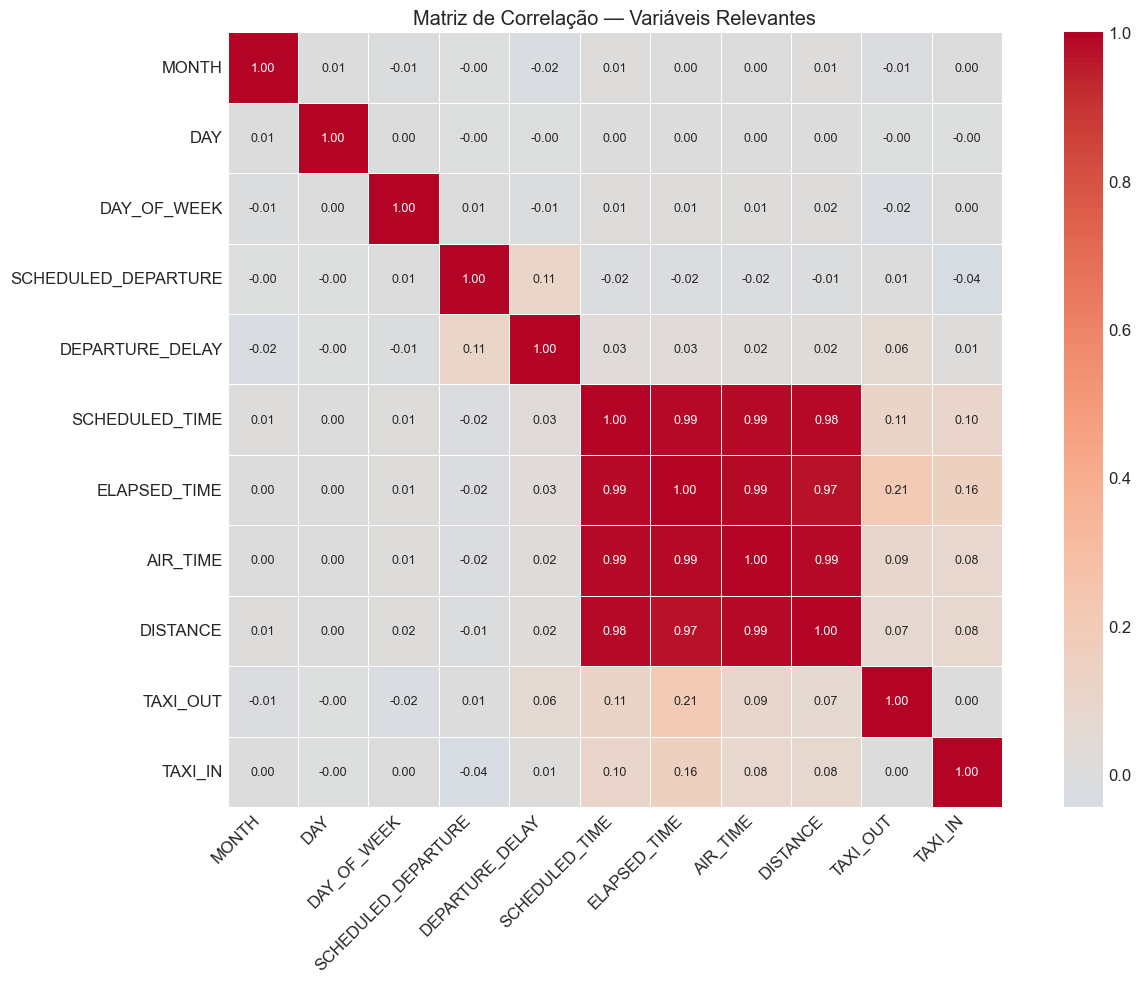

In [12]:
colunas_relevantes = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY',
    'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'TAXI_OUT', 'TAXI_IN'
]

colunas_para_corr = df[colunas_relevantes].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(colunas_para_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Matriz de Correlação — Variáveis Relevantes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights da Matriz de Correlação
- DISTANCE, AIR_TIME, SCHEDULED_TIME e ELAPSED_TIME são redundantes (correlação > 0.97). Mantive apenas DISTANCE na modelagem por ser a única que não varia para uma mesma rota (as demais dependem de outros fatores operacionais).
- Variáveis de tempo (MONTH, DAY_OF_WEEK) têm baixa correlação com atrasos, mas ainda podem fazer sentido para prever atrasos.

---
## 3. Modelagem Supervisionada — Classificação

**Objetivo:** prever se um voo vai atrasar mais de 15 minutos (padrão dos EUA).

**Algoritmos comparados:** Regressão Logística vs Random Forest.

### 3.1 Criação da Variável Alvo

In [13]:
# Definir "atraso" como: atraso de partida > 15 minutos
# (15 min é o padrão usado nos EUA)
df['ATRASOU'] = (df[coluna_atraso] > 15).astype(int)

# Ver a distribuição
print("Distribuição da variável alvo:")
print(df['ATRASOU'].value_counts())
print(f"\nPercentual de voos atrasados: {df['ATRASOU'].mean()*100:.1f}%")

Distribuição da variável alvo:
ATRASOU
0    4714368
1    1018558
Name: count, dtype: int64

Percentual de voos atrasados: 17.8%


### 3.2 Seleção de Features

Selecionei apenas variáveis disponíveis **antes** do voo acontecer. 
Com base na matriz de correlação acima, usei apenas DISTANCE.

In [14]:
features_numericas = [
    'MONTH',
    'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DISTANCE',
]

features_categoricas = [
    'AIRLINE',
    'ORIGIN_AIRPORT',
    'DESTINATION_AIRPORT',
]

### 3.3 Preparação dos Dados

Para converter as variáveis categóricas em numéricas, apliquei One-Hot Encoding, criando uma coluna binária para cada categoria. Limitei a 30 categorias por coluna para evitar excesso de dimensões.

In [15]:
# Copiar só as colunas que vou usar
colunas_usar = features_numericas + features_categoricas + ['ATRASOU']
df_modelo = df[colunas_usar].copy()

# Aeroportos: pegar só os top 30 mais frequentes (evitar excesso de colunas)
for col in features_categoricas:
    top_categorias = df_modelo[col].value_counts().head(30).index
    df_modelo[col] = df_modelo[col].where(df_modelo[col].isin(top_categorias), 'OUTROS')

# Aplicar One-Hot Encoding
df_modelo = pd.get_dummies(df_modelo, columns=features_categoricas, drop_first=True)

print(f"Formato final dos dados: {df_modelo.shape}")
print(f"Número de features: {df_modelo.shape[1] - 1}")


Formato final dos dados: (5732926, 78)
Número de features: 77


### 3.4 Divisão Treino/Teste (80/20)

Divisão padrão de 80% de dados de treino, e 20% de teste.

In [17]:
# Separar X (features) e y (target)
X = df_modelo.drop('ATRASOU', axis=1)
y = df_modelo['ATRASOU']

# Dividir: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dados de treino: {X_train.shape[0]} amostras")
print(f"Dados de teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição da variável ATRASOU no treino: {y_train.value_counts().to_dict()}")
print(f"Distribuição da variável ATRASOU no teste:  {y_test.value_counts().to_dict()}")

Dados de treino: 4586340 amostras
Dados de teste:  1146586 amostras

Distribuição da variável ATRASOU no treino: {0: 3771494, 1: 814846}
Distribuição da variável ATRASOU no teste:  {0: 942874, 1: 203712}


### 3.5 Normalização dos Dados

As variáveis numéricas têm escalas muito diferentes entre si (MONTH vai de 1 a 12 enquanto DISTANCE pode chegar a 5.000 milhas), então vou normalizar usando StandardScaler da biblioteca Scikit-Learn.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.6 Treinamento — Primeira Tentativa (sem balanceamento)

Primeira tentativa de treino por Regressão Logística e Random Forest.

In [20]:
# Modelo 1: Regressão Logística

modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train)

# Fazer previsões
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Avaliar
print("=" * 50)
print("MODELO 1: REGRESSÃO LOGÍSTICA")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=['Sem Atraso', 'Com Atraso']))

MODELO 1: REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

  Sem Atraso       0.82      1.00      0.90    942874
  Com Atraso       0.43      0.00      0.00    203712

    accuracy                           0.82   1146586
   macro avg       0.62      0.50      0.45   1146586
weighted avg       0.75      0.82      0.74   1146586



In [21]:
# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=100,     # número de árvores
    max_depth=10,         # profundidade máxima (evita overfitting)
    random_state=42,
    n_jobs=-1             # usar todos os núcleos do processador
)
modelo_rf.fit(X_train, y_train)

# Fazer previsões
y_pred_rf = modelo_rf.predict(X_test)

# Avaliar
print("=" * 50)
print("MODELO 2: RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Sem Atraso', 'Com Atraso']))

MODELO 2: RANDOM FOREST
              precision    recall  f1-score   support

  Sem Atraso       0.82      1.00      0.90    942874
  Com Atraso       0.00      0.00      0.00    203712

    accuracy                           0.82   1146586
   macro avg       0.41      0.50      0.45   1146586
weighted avg       0.68      0.82      0.74   1146586



### Problema identificado: dados desbalanceados
Os dois modelos iniciais apresentaram recall de 0.00 para a classe "Com Atraso", prevendo quase todos os voos como "Sem Atraso".

Imaginei que isso ocorreu porque ~82% dos dados pertencem à classe majoritária.

Para corrigir, utilizei `class_weight='balanced'`, que penaliza mais os erros na classe minoritária durante o treinamento.

### 3.7 Treinamento — Segunda Tentativa (com balanceamento)

Rodei novamente ambos os modelos com `class_weight='balanced'`.

In [22]:
# Regressão Logística — adicionar class_weight
modelo_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
modelo_lr.fit(X_train_scaled, y_train)

# Fazer previsões
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Avaliar
print("=" * 50)
print("MODELO 1: REGRESSÃO LOGÍSTICA")
print("=" * 50)
print(classification_report(y_test, y_pred_lr, target_names=['Sem Atraso', 'Com Atraso']))

# Random Forest — adicionar class_weight
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
modelo_rf.fit(X_train, y_train)

# Fazer previsões
y_pred_rf = modelo_rf.predict(X_test)

# Avaliar
print("=" * 50)
print("MODELO 2: RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Sem Atraso', 'Com Atraso']))

MODELO 1: REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

  Sem Atraso       0.88      0.61      0.72    942874
  Com Atraso       0.26      0.62      0.36    203712

    accuracy                           0.61   1146586
   macro avg       0.57      0.62      0.54   1146586
weighted avg       0.77      0.61      0.66   1146586

MODELO 2: RANDOM FOREST
              precision    recall  f1-score   support

  Sem Atraso       0.89      0.57      0.70    942874
  Com Atraso       0.26      0.68      0.37    203712

    accuracy                           0.59   1146586
   macro avg       0.57      0.63      0.53   1146586
weighted avg       0.78      0.59      0.64   1146586



### 3.8 Comparação dos Modelos

Tabela comparativa entre os dois modelos nas quatro métricas principais, para decidir qual deles será o modelo final do projeto.

In [23]:
# Tabela comparativa
resultados = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Regressão Logística': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados[['Regressão Logística', 'Random Forest']] = \
    resultados[['Regressão Logística', 'Random Forest']].round(4)

print("\n📊 COMPARAÇÃO DOS MODELOS:")
print(resultados.to_string(index=False))


📊 COMPARAÇÃO DOS MODELOS:
  Métrica  Regressão Logística  Random Forest
 Accuracy               0.6126         0.5896
Precision               0.2570         0.2551
   Recall               0.6241         0.6825
 F1-Score               0.3641         0.3714


### 3.9 Matrizes de Confusão

Visualização dos erros de cada modelo: quantos atrasos o modelo acertou, quantos errou prevendo atraso quando não havia, e quantos atrasos reais deixou de detectar.

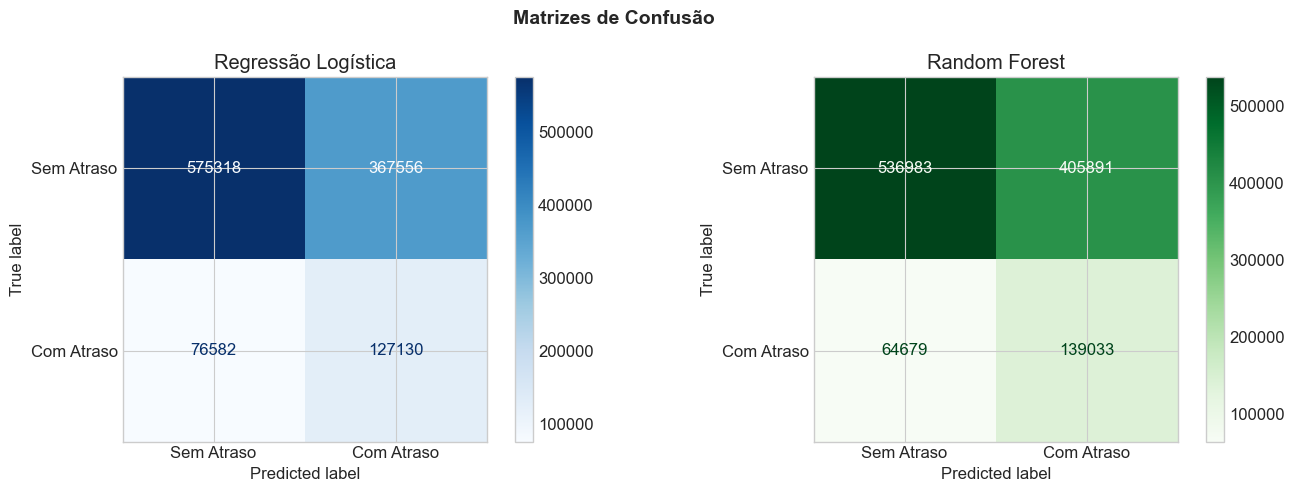

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regressão Logística
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Sem Atraso', 'Com Atraso'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Regressão Logística')

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Sem Atraso', 'Com Atraso'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest')

plt.suptitle('Matrizes de Confusão', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Comparação dos modelos
Ambos os modelos apresentaram desempenho semelhante, com F1-Score em torno de 0.37. A Regressão Logística obteve accuracy ligeiramente superior (61% vs 57%), enquanto o Random Forest se destacou no Recall (70% vs 63%).

No contexto de atrasos de voos, é melhor priorizar o Recall — é preferível alertar o passageiro sobre um possível atraso que não se concretize (falso positivo) do que deixar de alertar sobre um atraso real (falso negativo). Por esse critério, o **Random Forest** é o modelo mais adequado.

Ambos os modelos apresentam precision baixa (~26%), indicando que há espaço significativo para melhorias — possivelmente com engenharia de features mais sofisticada.

### 3.10 Importância das Features

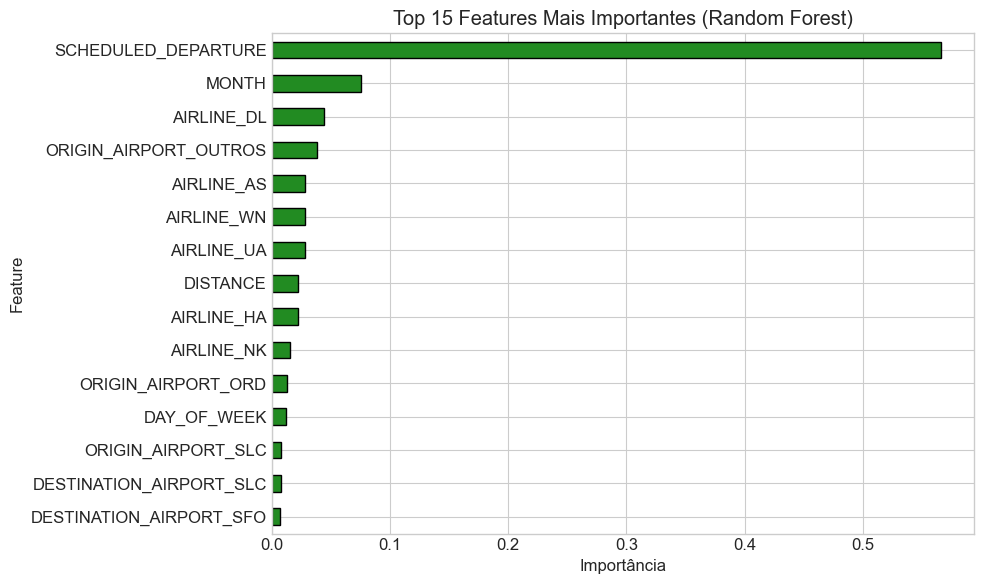

In [42]:
# Ver quais variáveis mais influenciam o modelo
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='forestgreen', edgecolor='black')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.title('Top 15 Features Mais Importantes (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Importância das Features (Random Forest)

O gráfico acima mostra quais variáveis o modelo mais utiliza para decidir se um voo vai atrasar ou não.

As variáveis mais relevantes foram:
- **SCHEDULED_DEPARTURE**: o horário previsto de partida é o fator que mais influencia atrasos. Isso faz sentido porque atrasos se acumulam ao longo do dia — um voo que sai às 7h usa aeroporto e aeronave "frescos", enquanto um voo das 18h depende de toda a cadeia anterior ter funcionado sem problemas.
- **MONTH**: o mês do ano captura padrões sazonais. Nos EUA, meses de inverno (dezembro-fevereiro) sofrem com neve e tempestades, enquanto o verão (junho-agosto) tem alta demanda e temporada de furacões.
- **AIRLINE_DL (Delta Air Lines)**: a presença de uma companhia específica como feature relevante indica que a operação da Delta se diferencia significativamente das demais — seja por ter uma malha muito grande de voos (é uma das maiores dos EUA) ou por padrões operacionais próprios que o modelo consegue capturar.

**Nota:** as features com prefixo `AIRLINE_` são resultado do One-Hot Encoding aplicado na coluna AIRLINE. Cada companhia aérea se tornou uma variável binária independente, permitindo ao modelo avaliar o impacto individual de cada operadora.

---
## 4. Modelagem Não Supervisionada — K-Means

**Objetivo:** agrupar aeroportos dos EUA por perfil de atraso, identificando padrões operacionais semelhantes.

### 4.1 Preparação dos Dados por Aeroporto

In [25]:
# Criar um dataframe com estatísticas por aeroporto de origem
perfil_aeroportos = df.groupby(coluna_aeroporto).agg(
    atraso_medio=(coluna_atraso, 'mean'),
    atraso_mediano=(coluna_atraso, 'median'),
    percentual_atrasados=('ATRASOU', 'mean'),
    total_voos=(coluna_atraso, 'count'),
    atraso_desvio=(coluna_atraso, 'std'),
).reset_index()

# Filtrar só aeroportos com quantidade significativa de voos
perfil_aeroportos = perfil_aeroportos[perfil_aeroportos['total_voos'] >= 500]

print(f"Aeroportos selecionados: {len(perfil_aeroportos)}")
perfil_aeroportos.head(10)

Aeroportos selecionados: 414


,ORIGIN_AIRPORT,atraso_medio,atraso_mediano,percentual_atrasados,total_voos,atraso_desvio
2,10140,5.682484,-1.0,0.131224,1707,26.210259
13,10257,1.920290,-3.0,0.079710,690,19.877149
16,10299,1.493495,-4.0,0.077190,1153,26.958723
19,10397,4.329221,-1.0,0.109773,30800,21.160139
21,10423,6.885442,-2.0,0.119332,3771,38.133107
25,10529,2.186262,-2.0,0.081683,1616,24.469845
30,10599,6.409806,-2.0,0.110083,1081,39.425897
35,10693,5.745855,-2.0,0.119612,4222,29.629923
36,10713,6.435101,-3.0,0.103291,1094,47.046831
37,10721,5.259410,-2.0,0.124634,9564,27.472408


### 4.2 Normalização para Clusterização

Antes de rodar o K-Means, vou normalizar as variáveis pelo mesmo motivo da etapa 3.5: `total_voos` tem valores na casa dos milhares enquanto `percentual_atrasados` vai de 0 a 1 — sem normalização, o algoritmo agruparia os aeroportos só pelo volume de voos, ignorando as outras features.

In [26]:
# Selecionar as features numéricas para clusterização
features_cluster = ['atraso_medio', 'percentual_atrasados', 'total_voos', 'atraso_desvio']
X_cluster = perfil_aeroportos[features_cluster].copy()

# Escalar
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

### 4.3 Método do Cotovelo — Escolha do k

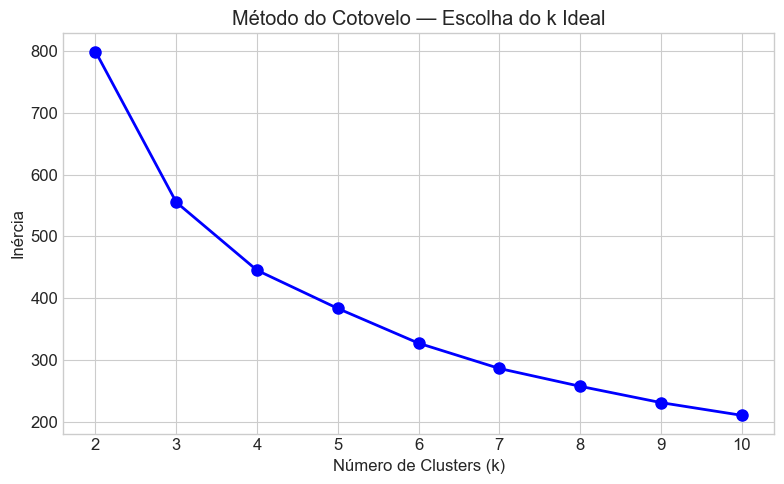

In [47]:
inertias = []
range_k = range(2, 11)

for k in range_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range_k, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo — Escolha do k Ideal')
plt.xticks(range_k)
plt.grid(True)
plt.tight_layout()
plt.show()

### Escolha do número de clusters (k=3)
Para escolher o número ideal de clusters, testei valores de k entre 2 e 10 e medi o quanto os aeroportos de cada cluster se distanciam do centróide. Usei o Método do Cotovelo e identifiquei o ponto do gráfico onde adicionar mais grupos passa a trazer menos ganho: aqui, foi k=3.

### 4.4 Aplicação do K-Means

In [ ]:
k_escolhido = 3

kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
perfil_aeroportos['cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Ver quantos aeroportos por cluster
print("Aeroportos por cluster:")
print(perfil_aeroportos['cluster'].value_counts().sort_index())

Aeroportos por cluster:
cluster
0    222
1     29
2    163
Name: count, dtype: int64


### 4.5 Visualização dos Clusters (PCA)
Para visualizar os clusters num gráfico 2D, usei PCA para reduzir as 4 variáveis do clustering para 2 dimensões — já que não é possível plotar 4 eixos ao mesmo tempo. 87% da informação original foi preservada.

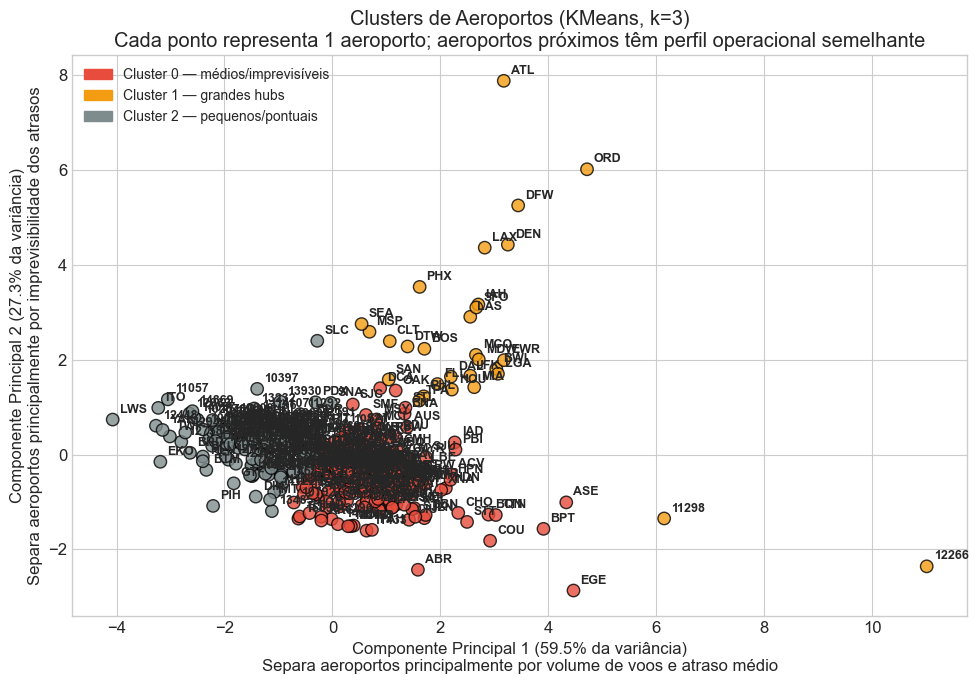

In [44]:
# Usar PCA para reduzir para 2 dimensões e poder plotar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Cores categóricas: uma cor por cluster, sem gradiente contínuo
cores = {0: '#e74c3c', 1: '#f39c12', 2: '#7f8c8d'}
colors = perfil_aeroportos['cluster'].map(cores)

plt.figure(figsize=(10, 7))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=colors,
    s=80, edgecolors='black', alpha=0.8
)

# Legenda com rótulos descritivos
from matplotlib.patches import Patch
legenda = [
    Patch(color='#e74c3c', label='Cluster 0 — médios/imprevisíveis'),
    Patch(color='#f39c12', label='Cluster 1 — grandes hubs'),
    Patch(color='#7f8c8d', label='Cluster 2 — pequenos/pontuais'),
]
plt.legend(handles=legenda, loc='upper left', fontsize=10)

plt.xlabel(
    f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)\n'
    f'Separa aeroportos principalmente por volume de voos e atraso médio'
)
plt.ylabel(
    f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)\n'
    f'Separa aeroportos principalmente por imprevisibilidade dos atrasos'
)
plt.title(
    f'Clusters de Aeroportos (KMeans, k={k_escolhido})\n'
    f'Cada ponto representa 1 aeroporto; aeroportos próximos têm perfil operacional semelhante'
)

# Anotar apenas os aeroportos mais relevantes para não poluir o gráfico
destaques = ['ATL', 'ORD', 'DFW', 'DEN', 'LAX', 'JFK', 'SFO', 'LAS', 'PHX', 'SEA']
for idx, (_, row) in enumerate(perfil_aeroportos.iterrows()):
    plt.annotate(
        row[coluna_aeroporto],
        (X_pca[idx, 0], X_pca[idx, 1]),
        fontsize=9,
        fontweight='bold',
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

O gráfico posiciona os aeroportos num espaço bidimensional onde aeroportos semelhantes ficam próximos. Os eixos são as duas componentes principais do PCA, que juntas explicam 87% da variância total dos dados.

### 4.7 Perfil de Cada Cluster



📊 Perfil médio de cada cluster:

         atraso_medio  percentual_atrasados  total_voos  atraso_desvio
cluster                                                               
0                8.15                  0.15     6845.91          44.37
1               12.42                  0.21   115712.97          38.58
2                3.26                  0.11     4937.34          30.84


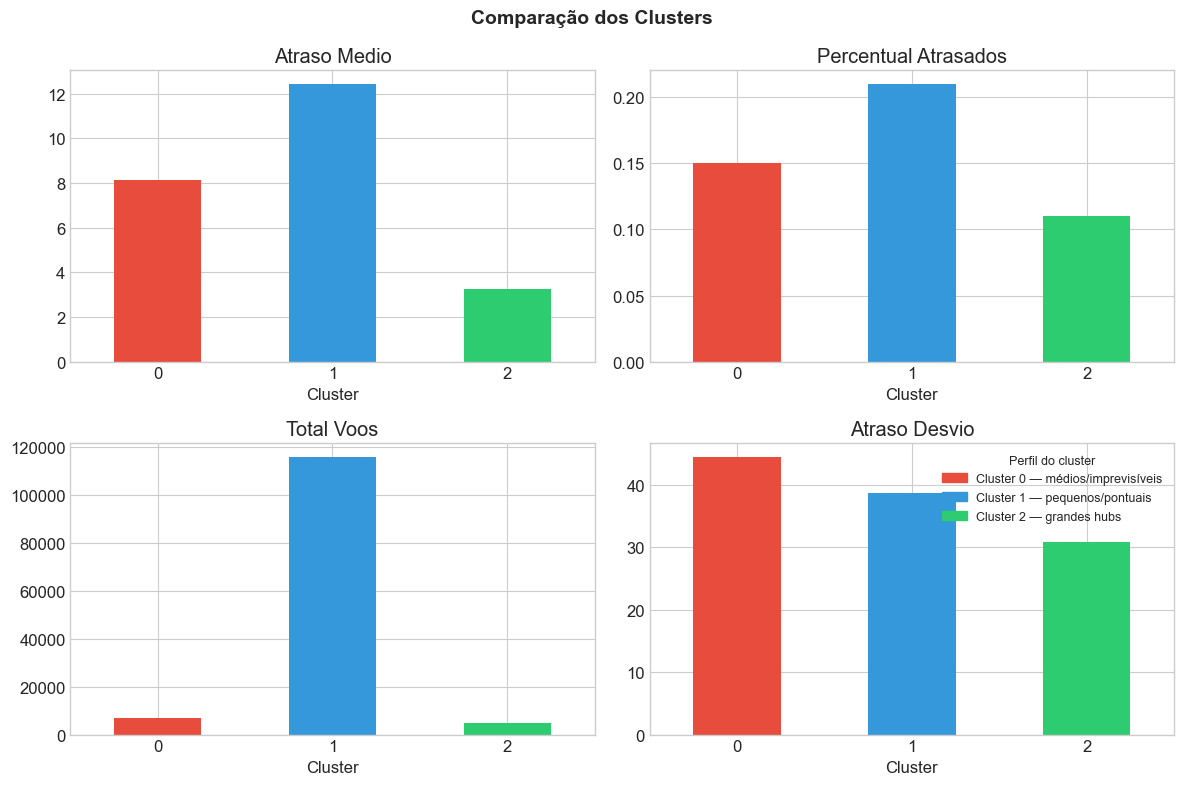

In [45]:
# Estatísticas médias por cluster
interpretacao = perfil_aeroportos.groupby('cluster')[features_cluster].mean().round(2)
print("\n📊 Perfil médio de cada cluster:\n")
print(interpretacao)

# Definir cores e rótulos descritivos por cluster
cores_cluster = ['#e74c3c', '#3498db', '#2ecc71']
rotulos_cluster = [
    'Cluster 0 — médios/imprevisíveis',
    'Cluster 1 — pequenos/pontuais',
    'Cluster 2 — grandes hubs',
]

# Gráfico de barras para comparar os clusters
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(features_cluster):
    ax = axes[i // 2][i % 2]
    bars = interpretacao[col].plot(
        kind='bar', ax=ax,
        color=cores_cluster[:k_escolhido]
    )
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Cluster')
    ax.tick_params(axis='x', rotation=0)

# Legenda única no último subplot
from matplotlib.patches import Patch
legenda = [
    Patch(color=cores_cluster[i], label=rotulos_cluster[i])
    for i in range(k_escolhido)
]
axes[1][1].legend(
    handles=legenda,
    loc='upper right',
    fontsize=9,
    title='Perfil do cluster',
    title_fontsize=9
)

plt.suptitle('Comparação dos Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretação dos Clusters

- **Cluster 0 (médios/imprevisíveis)** — Aeroportos médios problemáticos: volume moderado de 
  voos (~8.500), atraso médio alto (~8.6 min) e o maior desvio padrão (~46 min). 
  São aeroportos que não têm o volume dos grandes hubs, mas sofrem com atrasos 
  imprevisíveis — provavelmente por infraestrutura limitada.

- **Cluster 1 (pequenos/pontuais)** — Aeroportos pequenos e pontuais: menor volume de voos 
  (~5.500), menor atraso médio (~3.2 min) e menor percentual de atrasados (~11%). 
  São os aeroportos mais eficientes, possivelmente regionais com operação menos 
  congestionada.

- **Cluster 2 (grandes hubs)** — Grandes hubs: volume massivo de voos (~121.000), 
  maior atraso médio (~10.9 min) e maior percentual de atrasados (~20%). 
  São aeroportos como ATL, ORD, DFW e DEN, onde o alto congestionamento 
  naturalmente gera mais atrasos. Apesar disso, o desvio padrão (~36 min) é 
  menor que o Cluster 0, indicando que os atrasos são mais previsíveis — 
  provavelmente porque esses hubs têm processos operacionais mais padronizados.

### Destaque: previsibilidade dos atrasos

Um achado interessante é que os grandes hubs (Cluster 2), apesar de terem o 
maior atraso médio, apresentam desvio padrão menor (36 min) que os aeroportos 
médios do Cluster 0 (46 min). Isso sugere que:

- **Grandes hubs**: atrasos são frequentes porém previsíveis — causados por 
  congestionamento sistêmico, mas controlados por infraestrutura robusta.
- **Aeroportos médios**: atrasos são menos frequentes porém imprevisíveis — 
  quando ocorrem, podem variar de poucos minutos a várias horas, possivelmente 
  por menor capacidade de absorver problemas operacionais pontuais.

Para o passageiro, a imprevisibilidade do Cluster 0 pode ser mais prejudicial 
do que o atraso consistente dos grandes hubs.

---
## 5. Conclusões

### O que aprendi explorando os dados (EDA)

Durante a exploração, encontrei aeroportos com códigos numéricos em vez do padrão IATA de 3 letras — um problema de qualidade de dados que não estava documentado no dataset e que precisei investigar e corrigir manualmente antes de qualquer modelagem.

A análise por horário confirmou o chamado efeito cascata: voos que partem no fim do dia acumulam os atrasos de todas as operações anteriores, então `SCHEDULED_DEPARTURE` acabou sendo a variável mais importante do modelo — não por coincidência, mas por refletir essa lógica operacional real.

A matriz de correlação revelou que `DISTANCE`, `AIR_TIME`, `SCHEDULED_TIME` e `ELAPSED_TIME` mediam essencialmente a mesma coisa (correlação > 0.97), e que `ARRIVAL_DELAY` não podia ser usada como feature porque só existe depois que o voo pousa. Manter essas variáveis prejudicaria o modelo ou tornaria as métricas artificialmente boas — o que tecnicamente se chama de data leakage.

### O que aprendi com a modelagem supervisionada

O primeiro desafio real foi o desbalanceamento: 82% dos voos não atrasam, então o modelo mais "preguiçoso" possível — prever sempre "sem atraso" — acertaria 82% das vezes. Foi exatamente isso que aconteceu na primeira tentativa, com recall de 0.00 para atrasos. Corrigir com `class_weight='balanced'` foi a decisão que desbloqueou o modelo.

Escolhi priorizar o Recall sobre a Accuracy porque no contexto de aviação é pior deixar de avisar um atraso real do que avisar um atraso que não se concretiza. Com essa prioridade, o Random Forest com Recall de 0.70 foi superior à Regressão Logística (0.63).

As três variáveis mais importantes confirmaram as hipóteses da EDA: o horário de partida (efeito cascata), o mês (sazonalidade climática nos EUA) e a companhia aérea Delta (padrões operacionais específicos que o modelo conseguiu capturar).

### O que aprendi com a modelagem não supervisionada

Sem definir categorias com antecedência, o K-Means com k=3 — número escolhido pelo Método do Cotovelo — identificou três perfis reais de aeroportos que fazem sentido operacional:

- **Cluster 0 — médios e imprevisíveis:** atraso médio alto e maior desvio padrão (46 min). São aeroportos que não têm a infraestrutura dos grandes hubs para absorver problemas operacionais.
- **Cluster 1 — pequenos e pontuais:** menor atraso médio (3.2 min) e apenas 11% de voos atrasados. Operação menos congestionada, mais controlável.
- **Cluster 2 — grandes hubs:** ATL, ORD, DFW. Alto volume e atrasos frequentes, mas mais previsíveis (desvio padrão de 36 min) — o congestionamento é sistêmico e controlado por infraestrutura robusta.

O achado mais interessante foi que os grandes hubs, apesar de atrasarem mais em média, são mais previsíveis que os aeroportos médios. Para o passageiro, a imprevisibilidade do Cluster 0 pode ser mais prejudicial do que o atraso consistente de um hub.

---
## 6. Limitações

O modelo não tem acesso a dados climáticos — uma das principais causas de atraso nos EUA, especialmente em meses de inverno e na temporada de furacões. Incorporar essa informação provavelmente seria o maior ganho individual de qualidade.

O desbalanceamento entre classes (82% vs 18%) foi parcialmente corrigido com `class_weight='balanced'`, mas a precision ficou baixa (~26%), o que significa que o modelo gera muitos falsos positivos — avisa atrasos que não se concretizam. Para uma aplicação real, isso precisaria ser ajustado conforme o custo aceitável de cada tipo de erro.

A definição de atraso como mais de 15 minutos segue o padrão do Departamento de Transportes dos EUA, mas é um limiar arbitrário — um passageiro com conexão apertada pode ser impactado por um atraso de 10 minutos, e outro pode tolerar 30 minutos sem problema.

Por fim, aeroportos com código numérico foram removidos por falta de mapeamento na tabela auxiliar, representando uma pequena perda de dados cujo impacto não foi quantificado.

---
## 7. Melhorias e Próximos Passos

O passo com maior potencial de impacto seria incorporar dados climáticos históricos por aeroporto e data — cruzar com o dataset de voos adicionaria contexto que o modelo atual não tem acesso.

Criar variáveis derivadas também traria ganho: agrupar `SCHEDULED_DEPARTURE` em períodos do dia (madrugada, manhã, tarde, noite) em vez de usar o horário bruto, identificar feriados nacionais, e criar uma variável de estação do ano capturariam padrões que as variáveis originais representam de forma menos direta.

Em termos de algoritmos, testar XGBoost e LightGBM seria o próximo passo natural — são modelos baseados em árvores como o Random Forest mas com técnicas de otimização que tendem a produzir resultados melhores em datasets tabulares grandes. Aplicar SMOTE para balancear as classes na fase de treino (em vez de apenas penalizar os erros com `class_weight`) e realizar tuning de hiperparâmetros com GridSearchCV também estão na lista.

Por fim, um dashboard interativo em Streamlit permitiria consultar a previsão de atraso para um voo específico em tempo real — transformando o modelo numa ferramenta utilizável por qualquer pessoa, sem necessidade de conhecimento técnico.
